##  Proposta de solução com modelo preditivo

### 🎯 Estratégia adotada  
Foi adotada uma abordagem de **regressão**, com o objetivo de prever o valor do NPS em escala contínua (0 a 10), utilizando dados operacionais como entrega, atendimento e características do pedido.

---

### ⚙️ Justificativa técnica  
A escolha pela regressão se deve ao fato de o NPS ser uma variável numérica contínua.  
Essa abordagem permite capturar com maior precisão as variações na satisfação do cliente, mantendo um nível mais alto de detalhamento na previsão.

---

### 💼 Justificativa de negócio  
A previsão contínua do NPS possibilita identificar, com antecedência, clientes com maior risco de insatisfação.

Com isso, a empresa pode:
- Atuar de forma preventiva na jornada do cliente  
- Priorizar atendimentos mais críticos  
- Reduzir impactos negativos na experiência  
- Melhorar retenção e fidelização  

---

### 🔄 Abordagem alternativa  
Uma alternativa seria a utilização de modelos de **classificação**, categorizando os clientes em promotores, neutros e detratores.

Apesar de mais simples, essa abordagem reduz a granularidade da informação, podendo limitar a capacidade de análise e priorização.

---

### ✅ Conclusão  
A utilização de regressão se mostra mais adequada ao problema, pois permite previsões mais detalhadas e apoia decisões mais estratégicas e proativas na gestão da experiência do cliente.

# 1. Importando a Base de Dados

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_palette('Accent')
sns.set_theme(style='darkgrid')

In [5]:
# Fazendo a leitura da base de dados
dados = pd.read_csv('../data/NPS.csv')
dados.head()

,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
0,1,63,Nordeste,14,50001,139.73,4,39.35,4,2,2,55.53,3,0,4,6.9,0,3,6.5
1,2,20,Sul,1,50002,458.95,2,9.51,10,6,4,28.23,3,0,10,2.4,0,3,0.0
2,3,46,Nordeste,111,50003,507.06,5,42.82,6,6,1,40.99,1,4,5,4.8,0,7,1.5
3,4,52,Centro-Oeste,117,50004,302.19,2,19.58,9,5,2,35.24,3,1,11,5.9,0,4,0.3
4,5,56,Norte,50,50005,253.06,1,29.37,11,13,1,39.32,1,1,0,6.1,0,3,7.9


## 2. Análises Preliminares


###  Verificação da estrutura do dataset
Foi utilizado o método `dados.info()` para entender a estrutura geral do dataset, incluindo:
- Tipos de dados de cada coluna  
- Quantidade de registros  
- Presença de valores nulos  


In [6]:
dados.info()

<class 'pandas.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customer_id                2500 non-null   int64  
 1   customer_age               2500 non-null   int64  
 2   customer_region            2500 non-null   str    
 3   customer_tenure_months     2500 non-null   int64  
 4   order_id                   2500 non-null   int64  
 5   order_value                2500 non-null   float64
 6   items_quantity             2500 non-null   int64  
 7   discount_value             2500 non-null   float64
 8   payment_installments       2500 non-null   int64  
 9   delivery_time_days         2500 non-null   int64  
 10  delivery_delay_days        2500 non-null   int64  
 11  freight_value              2500 non-null   float64
 12  delivery_attempts          2500 non-null   int64  
 13  customer_service_contacts  2500 non-null   int64  
 14  res

### Análise da variável categórica
A coluna `customer_region` foi analisada por ser a única variável categórica do dataset.

- `unique()` foi utilizado para identificar as regiões presentes  
- `value_counts()` para verificar a distribuição dos clientes por região  

Essa análise ajuda a entender a representatividade geográfica dos dados.


In [7]:
# Pegando os Dados únicos da coluna "customer_region"
dados['customer_region'].unique()

<ArrowStringArray>
['Nordeste', 'Sul', 'Centro-Oeste', 'Norte', 'Sudeste']
Length: 5, dtype: str

In [8]:
# Pegando a distribuição de cada região
dados['customer_region'].value_counts()

customer_region
Sul             521
Sudeste         520
Norte           506
Nordeste        485
Centro-Oeste    468
Name: count, dtype: int64

###  Verificação de dados nulos
Foi realizada a soma total de valores nulos no dataset utilizando `isnull().sum().sum()`.

Resultado:  
✔️ Não há dados nulos no dataset  

In [9]:
print(f'Total de Dados Nulos no Dataset : {dados.isnull().sum().sum()}')

Total de Dados Nulos no Dataset : 0


###  Verificação de dados duplicados
Foi feita a verificação de registros duplicados com `dados.duplicated().sum()`.

Resultado:  
✔️ Não há registros duplicados  

In [10]:
print(f'Total de Dados Duplicados : {dados.duplicated().sum()}')

Total de Dados Duplicados : 0


###  Estatística descritiva
Foi utilizada a função `describe()` para obter um resumo estatístico das variáveis numéricas, incluindo:

- Média  
- Desvio padrão  
- Valores mínimos e máximos  
- Quartis (25%, 50% e 75%)  

In [11]:
dados.describe().round(2)

,customer_id,customer_age,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
count,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00
mean,1250.50,43.40,61.32,51250.50,434.26,3.47,29.75,6.00,8.02,2.19,38.22,2.01,1.52,5.49,4.38,0.09,4.15,2.94
std,721.83,14.89,34.48,721.83,289.77,1.69,29.23,3.16,3.77,1.45,12.08,0.82,1.23,3.46,2.51,0.28,1.78,2.38
min,1.00,18.00,1.00,50001.00,7.76,1.00,0.02,1.00,2.00,0.00,2.62,1.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,625.75,31.00,31.00,50625.75,220.24,2.00,8.88,3.00,5.00,1.00,29.93,1.00,1.00,2.00,2.60,0.00,3.00,0.70
50%,1250.50,43.00,62.00,51250.50,375.52,3.00,20.94,6.00,8.00,2.00,38.50,2.00,1.00,6.00,4.40,0.00,4.00,2.80
75%,1875.25,56.00,91.00,51875.25,577.29,5.00,40.83,9.00,11.00,3.00,46.27,3.00,2.00,8.00,6.10,0.00,5.00,4.80
max,2500.00,69.00,119.00,52500.00,1983.81,6.00,230.33,11.00,14.00,8.00,76.13,3.00,7.00,11.00,10.00,1.00,11.00,10.00


# 3. Análises Gráficas

### Boxplot do NPS
Foi utilizado um boxplot para visualizar a distribuição do NPS e identificar possíveis outliers.

Observações:
- Os valores estão distribuídos entre 0 e 10  
- Não há presença significativa de outliers  
- A mediana está próxima de 4, indicando uma tendência a avaliações mais baixas

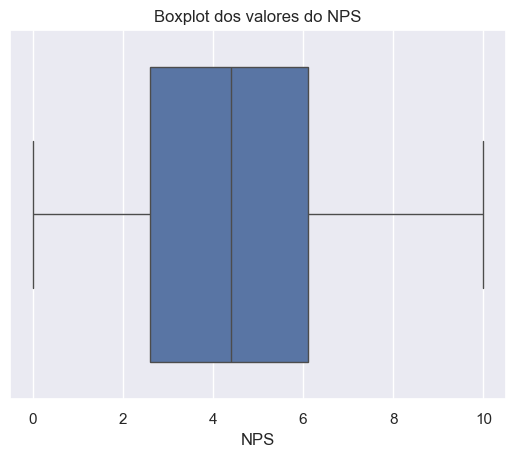

In [12]:
sns.boxplot(data=dados, x='nps_score')
plt.title('Boxplot dos valores do NPS')
plt.xlabel('NPS')
plt.show()

###  Estatística descritiva do NPS
Foi analisado o resumo estatístico da variável `nps_score`.

Principais pontos:
- Média: aproximadamente 4.38  
- Mediana: aproximadamente 4.40  
- Desvio padrão: 2.51  
- Intervalo: de 0 a 10  

Isso indica que a maior parte das avaliações está concentrada em níveis mais baixos de satisfação.


In [13]:
dados['nps_score'].describe().round(2)

count    2500.00
mean        4.38
std         2.51
min         0.00
25%         2.60
50%         4.40
75%         6.10
max        10.00
Name: nps_score, dtype: float64

###  Histograma do NPS
O histograma foi utilizado para visualizar a frequência das notas de NPS.

Observações:
- A distribuição apresenta maior concentração entre valores baixos e médios  
- Há menor frequência de notas altas (promotores)  
- Indica uma predominância de clientes menos satisfeitos  

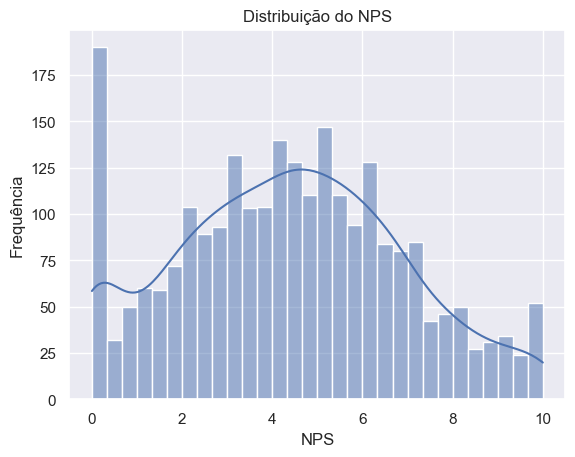

In [14]:
sns.histplot(data=dados, x='nps_score', bins=30, kde=True)
plt.title('Distribuição do NPS')
plt.xlabel('NPS')
plt.ylabel('Frequência')
plt.show()

## Análise Gráfica da Relação entre as Variáveis


In [15]:
# pegando a correlação apenas dos dados numéricos
correlacao = dados.select_dtypes(include=[np.number]).corr().round(2)

###  Mapa de correlação (Heatmap)
Foi gerado um mapa de correlação entre as variáveis numéricas para identificar relações lineares entre elas.


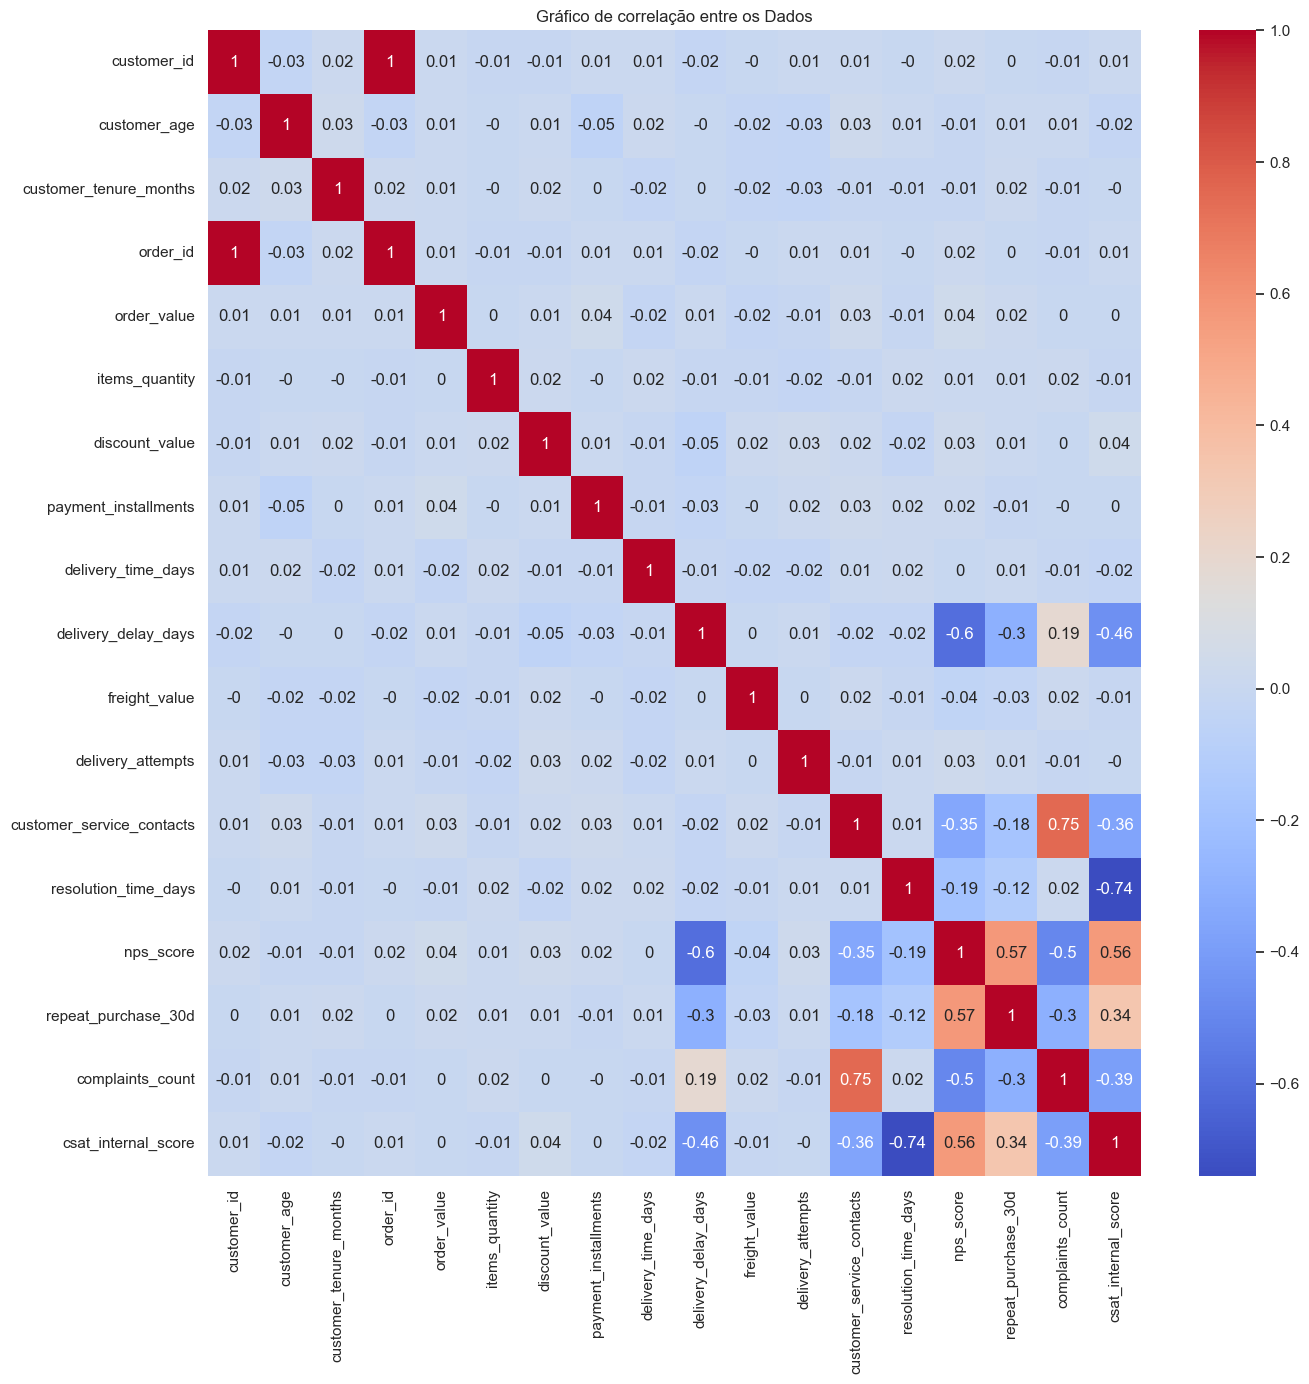

In [16]:
ax = plt.subplots(figsize=(14,14))
ax = sns.heatmap(correlacao, annot=True, cmap='coolwarm')
plt.title('Gráfico de correlação entre os Dados')
plt.tight_layout()
plt.show()

Pegando os valores numéricos com mair correlação : "delivery_delay_days", "customer_service_contacts", "repeat_purchase_30d", "complaints_count", "csat_internal_score"

###  Relação das variáveis com o NPS (Pairplot)
Foi utilizado um gráfico de dispersão (pairplot) para analisar a relação entre o NPS e algumas variáveis relevantes.

Principais insights:

- **delivery_delay_days:**  
  Apresenta relação negativa com o NPS — quanto maior o atraso, menor a satisfação  

- **customer_service_contacts:**  
  Clientes com mais contatos com o atendimento tendem a ter NPS mais baixo  

- **complaints_count:**  
  Forte relação negativa — mais reclamações estão associadas a menor satisfação  

- **csat_internal_score:**  
  Relação positiva clara — quanto maior o score interno, maior o NPS  

- **repeat_purchase_30d:**  
  Clientes que realizam recompra tendem a apresentar NPS mais alto  


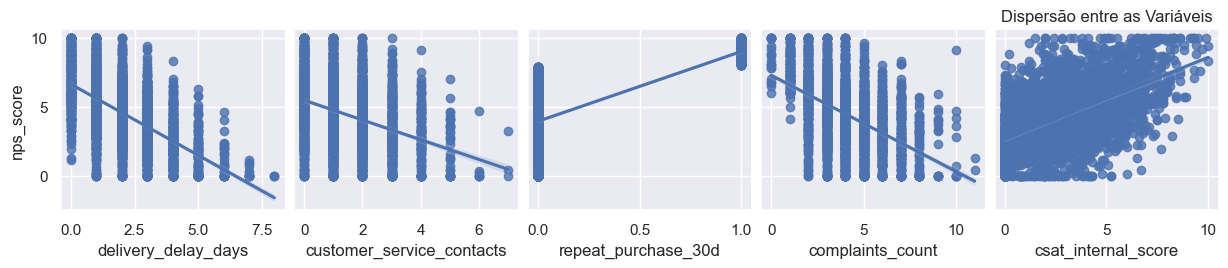

In [17]:
sns.pairplot(data=dados, y_vars='nps_score', x_vars=['delivery_delay_days','customer_service_contacts','repeat_purchase_30d', 'complaints_count', 'csat_internal_score'], kind='reg')
plt.title('Dispersão entre as Variáveis')
plt.show()

## Distribuição das Variáveis

Análise da distribuição das variáveis numéricas do dataset.

**Principais insights:**
- Variáveis como `order_value` e `discount_value` apresentam assimetria à direita (cauda longa)
- `freight_value` e `delivery_time_days` possuem distribuição mais concentrada
- Variáveis discretas (`items_quantity`, `delivery_attempts`, `customer_service_contacts`) apresentam poucos níveis
- `nps_score` apresenta distribuição contínua, concentrada entre valores médios

**Impacto no modelo:**
- Presença de assimetria pode influenciar modelos lineares
- Modelos baseados em árvore (como Gradient Boosting) lidam melhor com essas distribuições

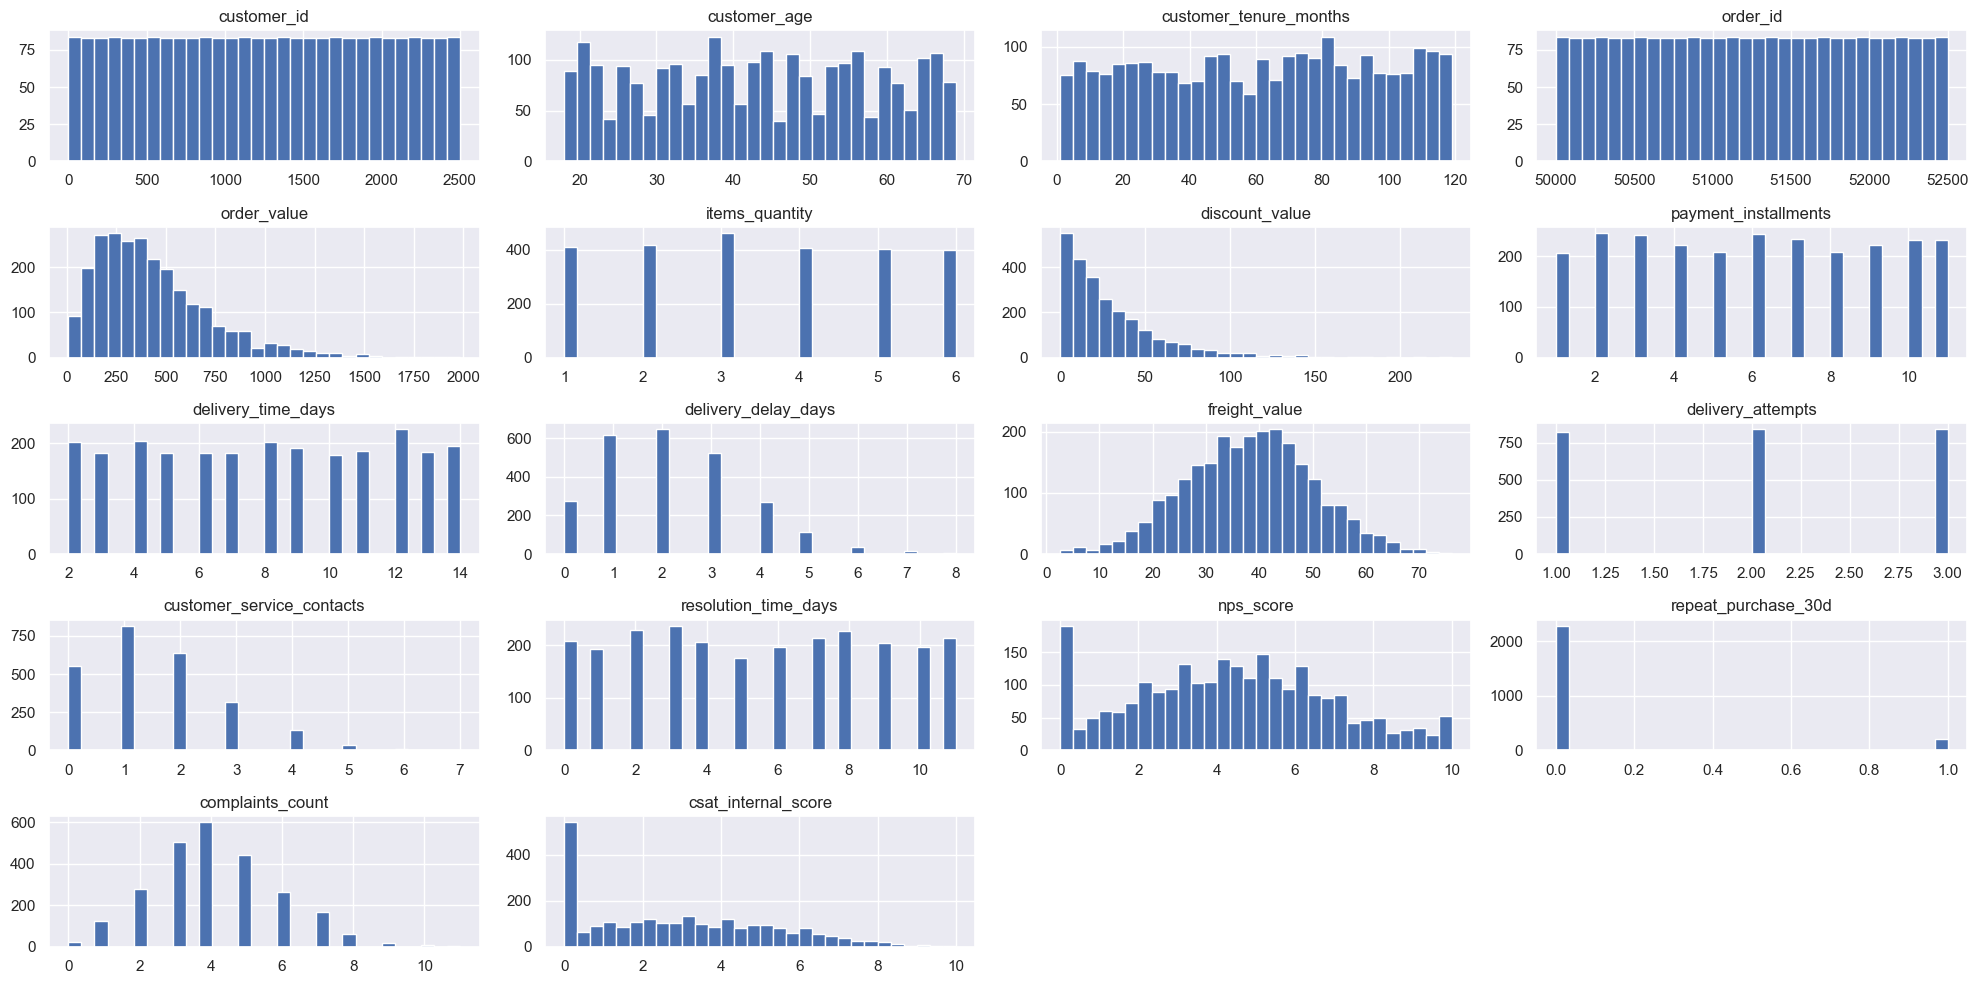

In [18]:
dados.hist(bins=30,figsize=(20,10))
plt.tight_layout()
plt.show()

## Feature Engineering

Criação de variáveis derivadas com base nos insights obtidos durante a análise exploratória (EDA).

**O que foi feito:**
- `entrega_problematica`: identifica casos com atraso na entrega e múltiplas tentativas
- `cliente_muito_acionado`: identifica clientes com alto volume de contatos com o atendimento

**Motivação:**
- Durante o EDA, atraso, tentativas de entrega e contatos com atendimento mostraram forte relação com o NPS
- As novas variáveis consolidam esses sinais em indicadores mais diretos de risco

**Impacto no modelo:**
- Melhora a capacidade do modelo de capturar padrões de insatisfação
- Reduz a complexidade ao transformar múltiplas variáveis em sinais mais interpretáveis

In [19]:
dados['entrega_problematica'] = ((dados['delivery_delay_days'] > 0) & (dados['delivery_attempts'] > 1)).astype(int)
dados['cliente_muito_acionado'] = (dados['customer_service_contacts'] >= 3).astype(int)

In [20]:
dados.head()

,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,...,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score,entrega_problematica,cliente_muito_acionado
0,1,63,Nordeste,14,50001,139.73,4,39.35,4,2,...,55.53,3,0,4,6.9,0,3,6.5,1,0
1,2,20,Sul,1,50002,458.95,2,9.51,10,6,...,28.23,3,0,10,2.4,0,3,0.0,1,0
2,3,46,Nordeste,111,50003,507.06,5,42.82,6,6,...,40.99,1,4,5,4.8,0,7,1.5,0,1
3,4,52,Centro-Oeste,117,50004,302.19,2,19.58,9,5,...,35.24,3,1,11,5.9,0,4,0.3,1,0
4,5,56,Norte,50,50005,253.06,1,29.37,11,13,...,39.32,1,1,0,6.1,0,3,7.9,0,0


# 4. Criação de Categorias e Amostragem Estratificada

###  Distribuição do NPS
Inicialmente, foi analisada a distribuição da variável `nps_score` por meio de um histograma.

Observações:
- Os valores estão distribuídos entre 0 e 10  
- Há maior concentração de clientes em faixas mais baixas e intermediárias  
- Indica predominância de clientes neutros e detratores  

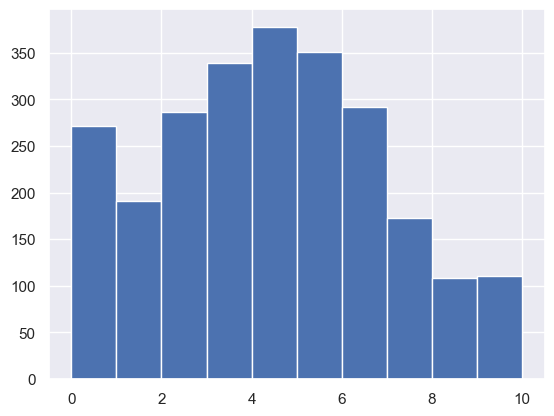

In [21]:
dados['nps_score'].hist()
plt.show()

###  Criação das categorias de NPS
Para viabilizar a estratificação dos dados, o NPS foi segmentado em categorias:

- **Detratores:** 0 a 6  
- **Neutros:** 6 a 8  
- **Promotores:** 8 a 10  

Essa categorização permite representar diferentes perfis de satisfação dos clientes.

In [22]:
dados['classe'] = pd.cut(dados['nps_score'],
                         bins=[-1, 6., 8., np.inf],
                         labels=['Detratores', 'Neutros', 'Promotores'])

In [23]:
dados['classe'].value_counts()

classe
Detratores    1851
Neutros        448
Promotores     201
Name: count, dtype: int64

###  Amostragem estratificada
A divisão entre treino e teste foi realizada de forma estratificada, utilizando a variável categórica criada.

Objetivo:
- Manter a mesma proporção de clientes (detratores, neutros e promotores) nos conjuntos de treino e teste  
- Evitar viés na modelagem  
- Garantir melhor capacidade de generalização do modelo  

In [24]:
X = dados.drop('nps_score',axis=1)
y = dados['nps_score']

In [25]:
from sklearn.model_selection import train_test_split

x_treino, x_teste, y_treino, y_teste = train_test_split(X, y, stratify=dados['classe'], test_size=0.2, random_state=123)

###  Validação da estratificação
Foi feita a comparação das proporções entre o dataset original e o conjunto de treino.

Resultado:
- As distribuições são praticamente idênticas  
- Confirma que a estratificação foi aplicada corretamente  

In [26]:
x_treino['classe'].value_counts(normalize=True)

classe
Detratores    0.7405
Neutros       0.1790
Promotores    0.0805
Name: proportion, dtype: float64

In [27]:
dados['classe'].value_counts(normalize=True)

classe
Detratores    0.7404
Neutros       0.1792
Promotores    0.0804
Name: proportion, dtype: float64

### Limpeza dos dados
Após a divisão, foram removidas variáveis que não agregam valor ao modelo:

- `classe` (usada apenas para estratificação)  
- `customer_id` e `order_id` (identificadores sem relevância preditiva)  

In [28]:
x_treino.drop(['classe', 'customer_id','order_id'], axis=1, inplace=True)
x_teste.drop(['classe', 'customer_id','order_id'], axis=1, inplace=True)

In [29]:
colunas_entrada = x_treino.columns

In [30]:
df = x_teste.copy()

# 5.   Pré-processamento dos dados


Preparação das variáveis para entrada nos modelos de machine learning.

**O que foi feito:**
- Padronização das variáveis numéricas com `StandardScaler`
- Codificação da variável categórica (`customer_region`) com `OneHotEncoder`
- Uso de `ColumnTransformer` para aplicar transformações de forma organizada
- Separação entre dados de treino e teste, evitando vazamento de informação

**Motivação:**
- Garantir que todas as variáveis estejam na mesma escala
- Transformar variáveis categóricas em formato numérico
- Preparar os dados de forma adequada para diferentes tipos de modelos

**Impacto no modelo:**
- Melhora a performance de modelos sensíveis à escala (ex: regressão, KNN)
- Mantém consistência entre treino e teste
- Estrutura escalável para novos dados

In [31]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [32]:
num_pipeline = Pipeline([
    ('std_scaler', StandardScaler())
])

In [33]:
numericos = ['customer_age', 'customer_tenure_months','order_value', 'items_quantity', 'discount_value', 'payment_installments', 'delivery_time_days', 'delivery_delay_days',
             'freight_value', 'delivery_attempts', 'customer_service_contacts', 'resolution_time_days', 'repeat_purchase_30d', 'complaints_count','csat_internal_score',
             'entrega_problematica', 'cliente_muito_acionado']
categoricos = ['customer_region']

In [34]:
full_pipeline = ColumnTransformer([
    ("num", num_pipeline, numericos),
    ("cat", OneHotEncoder(sparse_output=False), categoricos)
])

In [35]:
x_treino_tratado = full_pipeline.fit_transform(x_treino)
x_teste_tratado = full_pipeline.transform(x_teste)

In [36]:
num_cols = list(numericos)
cat_cols = full_pipeline.named_transformers_['cat'].get_feature_names_out(categoricos)

In [37]:
X_treino = pd.DataFrame(x_treino_tratado, columns=num_cols + list(cat_cols))
X_teste = pd.DataFrame(x_teste_tratado, columns=num_cols + list(cat_cols))

In [38]:
colunas_modelo = X_treino.columns

* Resultado Pré-Processamento

In [39]:
X_treino.head()

,customer_age,customer_tenure_months,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,...,repeat_purchase_30d,complaints_count,csat_internal_score,entrega_problematica,cliente_muito_acionado,customer_region_Centro-Oeste,customer_region_Nordeste,customer_region_Norte,customer_region_Sudeste,customer_region_Sul
0,-0.357808,1.614039,0.476507,0.897862,-1.014206,1.568082,-0.807531,-0.130065,-0.352609,-0.011130,...,-0.311597,-0.643727,0.817239,0.810556,-0.503123,0.0,0.0,0.0,1.0,0.0
1,0.380840,-1.564000,-1.171836,-1.477435,-0.272373,-0.956247,-0.271856,-0.831221,1.667295,1.225495,...,-0.311597,-0.643727,-0.902778,0.810556,-0.503123,0.0,1.0,0.0,0.0,0.0
2,-1.230756,-0.812827,1.957030,-0.289786,-0.687648,0.621458,-1.075369,1.272248,0.117098,-0.011130,...,-0.311597,2.135751,-1.238391,0.810556,1.987585,0.0,0.0,1.0,0.0,0.0
3,-0.827857,-1.650673,1.570964,1.491686,-0.620679,-1.587330,-0.004018,-0.130065,1.410866,1.225495,...,-0.311597,-1.755519,0.943093,0.810556,-0.503123,0.0,0.0,1.0,0.0,0.0
4,-1.230756,-1.130631,0.405620,-1.477435,-0.081824,0.305917,1.335172,-0.831221,-2.057993,-0.011130,...,-0.311597,0.468064,-0.944730,0.810556,1.987585,0.0,0.0,0.0,1.0,0.0


# 6. Modelos de Machine Learning

## Regressão Linear com StatsModels

In [40]:
import statsmodels.api as sm

In [41]:
X_treino = X_treino.reset_index(drop=True)
y_treino = y_treino.reset_index(drop=True)

### Treinamento
- Modelo OLS (`statsmodels`)
- Variável alvo: `nps_score`


In [42]:
x_treino_com_constante = sm.add_constant(X_treino)

modelo_stats_models = sm.OLS(y_treino, x_treino_com_constante).fit()

### Resultados
- R²: 0.649  
- R² ajustado: 0.646  
- Modelo estatisticamente significativo (p < 0.001)

### Principais insights
- **Impacto negativo:** atraso na entrega, reclamações, tempo de resolução, contatos com suporte  
- **Impacto positivo:** recompra em 30 dias, valor do pedido, região do cliente  

In [43]:
print(modelo_stats_models.summary())

                            OLS Regression Results                            
Dep. Variable:              nps_score   R-squared:                       0.651
Model:                            OLS   Adj. R-squared:                  0.647
Method:                 Least Squares   F-statistic:                     175.6
Date:                Fri, 17 Apr 2026   Prob (F-statistic):               0.00
Time:                        14:42:56   Log-Likelihood:                -3630.8
No. Observations:                2000   AIC:                             7306.
Df Residuals:                    1978   BIC:                             7429.
Df Model:                          21                                         
Covariance Type:            nonrobust                                         
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const           

## Avaliação de Modelos de Machine Learning

Treinamento e comparação de diferentes algoritmos de regressão para previsão do NPS.

**Modelos testados:**
- Linear Regression
- Decision Tree
- Random Forest
- Gradient Boosting
- KNN Regressor
- XGBoost
- LightGBM

In [44]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

from sklearn import metrics

In [45]:
modelos = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "KNN Regressor": KNeighborsRegressor(n_neighbors=5),
    "XGBoost": XGBRegressor(random_state=42),
    "LightGBM": LGBMRegressor(random_state=42, n_jobs=-1, verbose=-1)
}

In [46]:
resultados = []

for nome, modelo in modelos.items():
    modelo.fit(X_treino, y_treino)
    pred = modelo.predict(X_teste)

    mae = metrics.mean_absolute_error(y_teste, pred)
    rmse = np.sqrt(metrics.mean_squared_error(y_teste, pred))
    r2 = metrics.r2_score(y_teste, pred)

    resultados.append({
        "Modelo": nome,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

resultados_df = pd.DataFrame(resultados).sort_values(by="RMSE", ascending=True)

resultados_df.round(4)

,Modelo,MAE,RMSE,R2
3,Gradient Boosting,1.1458,1.4519,0.6586
2,Random Forest,1.1835,1.4830,0.6438
0,Linear Regression,1.1781,1.4964,0.6373
6,LightGBM,1.1918,1.5057,0.6329
5,XGBoost,1.2251,1.5496,0.6111
4,KNN Regressor,1.3019,1.6506,0.5587
1,Decision Tree,1.6150,2.0821,0.2979


**Principais resultados:**
- **Gradient Boosting** apresentou o melhor desempenho geral
- **Random Forest** também apresentou resultados consistentes
- Modelos de boosting (Gradient, XGBoost e LightGBM) se destacaram
- Decision Tree e KNN tiveram pior performance

**Decisão:**
Com base nos resultados, foram selecionados os modelos:
- Gradient Boosting
- XGBoost
- LightGBM

para etapa de **tuning de hiperparâmetros**, visando extrair melhor performance, dado o potencial desses algoritmos em capturar padrões mais complexos.

**Impacto no projeto:**
- Seleção baseada em evidência empírica
- Foco nos modelos com maior potencial de melhoria
- Preparação para otimização de performance

# 7. Tuning de Modelos

## Tuning — Gradient Boosting
Otimização dos hiperparâmetros do modelo Gradient Boosting utilizando `RandomizedSearchCV`.

**O que foi feito:**
- Definição de um espaço de busca para os principais hiperparâmetros:
  - `n_estimators`, `learning_rate`, `max_depth`
  - `min_samples_split`, `min_samples_leaf`, `subsample`
- Utilização de validação cruzada (cv=5)
- Métrica de otimização: **RMSE**

In [47]:
from sklearn.model_selection import RandomizedSearchCV

gb = GradientBoostingRegressor(random_state=42)

param_dist_gb = {
    "n_estimators": [100, 200, 300, 500],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "max_depth": [2, 3, 4, 5],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "subsample": [0.6, 0.8, 1.0]
}

gb_random = RandomizedSearchCV(
    gb,
    param_distributions=param_dist_gb,
    n_iter=30,
    cv=5,
    scoring="neg_root_mean_squared_error",
    verbose=1,
    random_state=42,
    n_jobs=-1
)

gb_random.fit(X_treino, y_treino)

print("Melhores parâmetros:", gb_random.best_params_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Melhores parâmetros: {'subsample': 0.8, 'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_depth': 4, 'learning_rate': 0.01}


**Resultado:**
- MAE: **1.1478**  
- RMSE: **1.4498**  
- R²: **0.6596**

**Insight:**
- O modelo apresentou leve melhora em relação à versão inicial
- Learning rate baixo combinado com mais árvores indicou melhor generalização

In [48]:
gradiente_boost = gb_random.best_estimator_

pred = gradiente_boost.predict(X_teste)

print("MAE:", metrics.mean_absolute_error(y_teste, pred))
print("RMSE:", np.sqrt(metrics.mean_squared_error(y_teste, pred)))
print("R2:", metrics.r2_score(y_teste, pred))

MAE: 1.1478128833487495
RMSE: 1.449793008208445
R2: 0.6595930188569177


## Tuning — XGBoost


Otimização dos hiperparâmetros do modelo XGBoost utilizando `RandomizedSearchCV`.

**O que foi feito:**
- Definição de um espaço de busca mais robusto, incluindo:
  - `n_estimators`, `learning_rate`, `max_depth`
  - `subsample`, `colsample_bytree`
  - `gamma`, `reg_alpha`, `reg_lambda` (regularização)
- Utilização de validação cruzada (cv=5)
- Métrica de otimização: **RMSE**

In [49]:
from xgboost import XGBRegressor

xgb = XGBRegressor(random_state=42, n_jobs=-1)

param_dist_xgb = {
    "n_estimators": [200, 300, 500],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "max_depth": [3, 4, 5, 6, 8],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "gamma": [0, 0.1, 0.3],
    "reg_alpha": [0, 0.1, 1],
    "reg_lambda": [1, 1.5, 2]
}

xgb_random = RandomizedSearchCV(
    xgb,
    param_distributions=param_dist_xgb,
    n_iter=40,
    cv=5,
    scoring="neg_root_mean_squared_error",
    verbose=1,
    random_state=42,
    n_jobs=-1
)

xgb_random.fit(X_treino, y_treino)

print("Melhores parâmetros:", xgb_random.best_params_)

Fitting 5 folds for each of 40 candidates, totalling 200 fits
Melhores parâmetros: {'subsample': 1.0, 'reg_lambda': 2, 'reg_alpha': 1, 'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.03, 'gamma': 0.3, 'colsample_bytree': 1.0}


**Resultado:**
- MAE: **1.1538**  
- RMSE: **1.4591**  
- R²: **0.6552**

**Insight:**
- O modelo apresentou desempenho inferior ao Gradient Boosting
- Forte regularização e menor profundidade indicam tentativa de evitar overfitting
- Pode indicar que o dataset não exige alta complexidade

In [50]:
best_model = xgb_random.best_estimator_

pred = best_model.predict(X_teste)

print("MAE:", metrics.mean_absolute_error(y_teste, pred))
print("RMSE:", np.sqrt(metrics.mean_squared_error(y_teste, pred)))
print("R2:", metrics.r2_score(y_teste, pred))

MAE: 1.148578028729558
RMSE: 1.4578002734991775
R2: 0.6558224721030016


## Tuning — LightGBM

Otimização dos hiperparâmetros do modelo LightGBM utilizando `RandomizedSearchCV`.

**O que foi feito:**
- Definição de espaço de busca incluindo:
  - `n_estimators`, `learning_rate`
  - `num_leaves`, `max_depth`
  - `min_child_samples`, `subsample`, `colsample_bytree`
- Utilização de validação cruzada (cv=5)
- Métrica de otimização: **RMSE**

In [51]:
lgb = LGBMRegressor(random_state=42, n_jobs=-1, verbose=-1)

param_dist_lgb = {
    "n_estimators": [100, 200, 300, 500],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "num_leaves": [15, 31, 50],
    "max_depth": [-1, 3, 5, 10],
    "min_child_samples": [5, 10, 20],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

lgb_random = RandomizedSearchCV(
    lgb,
    param_distributions=param_dist_lgb,
    n_iter=40,
    cv=5,
    scoring="neg_root_mean_squared_error",
    verbose=1,
    random_state=42,
    n_jobs=-1
)

lgb_random.fit(X_treino, y_treino)

print("Melhores parâmetros:", lgb_random.best_params_)

Fitting 5 folds for each of 40 candidates, totalling 200 fits
Melhores parâmetros: {'subsample': 1.0, 'num_leaves': 31, 'n_estimators': 500, 'min_child_samples': 5, 'max_depth': 3, 'learning_rate': 0.01, 'colsample_bytree': 1.0}


**Resultado:**
- MAE: **1.1513**  
- RMSE: **1.4505**  
- R²: **0.6593**

**Insight:**
- Desempenho muito próximo ao Gradient Boosting
- Modelo conseguiu capturar bem os padrões do dataset
- Baixa profundidade sugere estrutura de dados relativamente simples

In [52]:
best_model = lgb_random.best_estimator_

pred = best_model.predict(X_teste)

print("MAE:", metrics.mean_absolute_error(y_teste, pred))
print("RMSE:", np.sqrt(metrics.mean_squared_error(y_teste, pred)))
print("R2:", metrics.r2_score(y_teste, pred))

MAE: 1.15129579342543
RMSE: 1.4504917944434879
R2: 0.659264794017478


##  Conclusão — Escolha do Modelo

Após a avaliação e otimização dos principais modelos de regressão, o **Gradient Boosting** apresentou o melhor desempenho geral, com menor erro (RMSE) e maior capacidade de explicação (R²).

Embora modelos como LightGBM tenham apresentado resultados muito próximos, o Gradient Boosting se destacou por sua consistência e estabilidade ao longo das etapas de validação.

**Decisão:**
O modelo de **Gradient Boosting** foi selecionado como modelo final para previsão do NPS.

**Justificativa:**
- Melhor desempenho nas métricas avaliadas  
- Boa capacidade de generalização  
- Menor sensibilidade a variações nos dados  

Com isso, o modelo será utilizado como base para geração de previsões e suporte às decisões de negócio.

# 8. Cross-Validate no modelo Gradient Boosting

Validação da performance do modelo utilizando **Cross-Validation (K-Fold)** para avaliar sua capacidade de generalização.

**O que foi feito:**
- Aplicação de validação cruzada com 5 folds
- Avaliação utilizando as métricas:
  - RMSE
  - MAE
  - R²

In [53]:
from sklearn.model_selection import cross_validate, KFold

validacao = KFold(n_splits=5, shuffle=True, random_state=123)

resultado_validacao = cross_validate(
    gradiente_boost,
    X_treino,
    y_treino,
    cv=validacao,
    scoring={
        "rmse": "neg_root_mean_squared_error",
        "mae": "neg_mean_absolute_error",
        "r2": "r2"
    },
    n_jobs=-1
)

**Resultados:**
- RMSE médio: **1.4856** (std: 0.04)  
- MAE médio: **1.1709** (std: 0.03)  
- R² médio: **0.6499** (std: 0.02)

**Insight:**
- Baixa variação entre os folds indica **modelo estável**
- Resultados consistentes mostram boa capacidade de generalização
- Pequena diferença em relação ao teste inicial indica leve otimismo no holdout (comportamento esperado)


In [54]:
import numpy as np

rmse = -resultado_validacao["test_rmse"]
mae = -resultado_validacao["test_mae"]
r2 = resultado_validacao["test_r2"]

print("RMSE por fold:", np.round(rmse, 4))
print("RMSE médio:", round(rmse.mean(), 4))
print("RMSE std:", round(rmse.std(), 4))

print("MAE por fold:", np.round(mae, 4))
print("MAE médio:", round(mae.mean(), 4))
print("MAE std:", round(mae.std(), 4))

print("R2 por fold:", np.round(r2, 4))
print("R2 médio:", round(r2.mean(), 4))
print("R2 std:", round(r2.std(), 4))

RMSE por fold: [1.4941 1.5316 1.5009 1.4901 1.4112]
RMSE médio: 1.4856
RMSE std: 0.04
MAE por fold: [1.1757 1.2083 1.1711 1.1832 1.1161]
MAE médio: 1.1709
MAE std: 0.0303
R2 por fold: [0.6267 0.626  0.6574 0.6546 0.6849]
R2 médio: 0.6499
R2 std: 0.022


# 9. Visualização dos Resultados do Modelo

###  Real vs. Previsto
Foi gerado um gráfico comparando os valores reais de NPS com os valores previstos pelo modelo, permitindo avaliar visualmente sua performance.

---




In [55]:
y_teste_previsto = gradiente_boost.predict(X_teste)

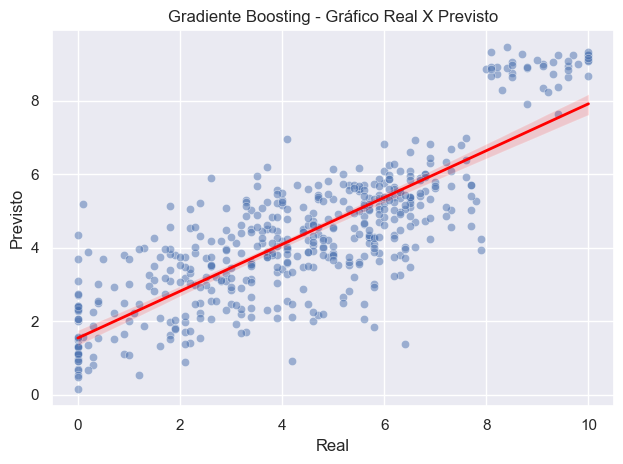

In [ ]:
sns.scatterplot(x=y_teste, y=y_teste_previsto, alpha=0.5)

sns.regplot(
        x=y_teste,
        y=y_teste_previsto,
        scatter=False,            
        color="red",              
        line_kws={"linewidth": 2} 
    )

plt.title("Gradiente Boosting - Gráfico Real X Previsto")
plt.xlabel("Real")
plt.ylabel("Previsto")
plt.tight_layout()
plt.show()

###  Interpretação
Observa-se uma relação linear positiva, indicando que o modelo acompanha a tendência dos dados.

A maioria dos pontos se concentra próxima à linha de tendência, sugerindo bom ajuste, embora ainda exista certa dispersão, principalmente nos valores extremos.

---

##  Análise dos resíduos

###  Avaliação dos erros
Foi gerado um gráfico de resíduos para analisar a diferença entre os valores reais e previstos pelo modelo.

---




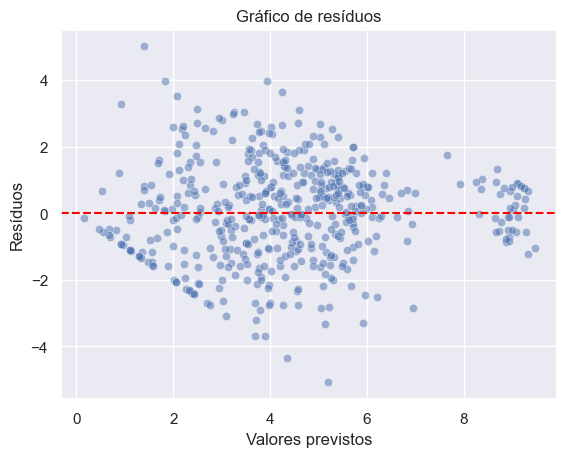

In [57]:
residuo = y_teste - y_teste_previsto

sns.scatterplot(x=y_teste_previsto, y=residuo, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Valores previstos")
plt.ylabel("Resíduos")
plt.title("Gráfico de resíduos")
plt.show()

###  Interpretação
Os resíduos estão distribuídos de forma relativamente aleatória em torno de zero, indicando que o modelo não apresenta viés evidente.

Observa-se uma leve dispersão, sugerindo variação nos erros, principalmente em alguns pontos extremos.

# 10. Geração de Valor para o E-commerce


A aplicação do modelo de Gradient Boosting permite transformar a previsão de NPS em **ações práticas de negócio**, conectando dados operacionais à tomada de decisão.

**O que foi feito:**
- Previsão do NPS para cada cliente (`previsao_nps`)
- Conversão da previsão em uma métrica de **risco de insatisfação**
- Segmentação dos clientes em níveis de risco:
  - Seguro
  - Neutro
  - Atenção
  - Crítico
- Definição de ações (ex: descontos) com base na segmentação
- Criação de uma métrica de **prioridade financeira** (`Risco × Valor do Pedido`)


In [58]:
# Trazendo o valor da previsão de NPS
df['previsao_nps'] = gradiente_boost.predict(X_teste)

In [59]:
df['Risco'] = (10 - df['previsao_nps']) / 10

In [60]:
df['Segmentacao_Cliente'] = pd.cut(df['Risco'],
                             bins=[-1., 0.4, 0.6, 0.8, np.inf],
                             labels=['Seguro', 'Neutro', 'Atenção', 'Crítico'])

In [61]:
def definir_desconto(segmento):
    if segmento == 'Crítico':
        return 40
    elif segmento == 'Atenção':
        return 20
    elif segmento == 'Neutro':
        return 10
    else:
        return 0

df['Desconto'] = df['Segmentacao_Cliente'].apply(definir_desconto)

In [62]:
df['Prioridade_Financeira'] = df['Risco'] * df['order_value']

##  Principais Insights

- Clientes com baixo NPS previsto são automaticamente classificados como maior risco
- A combinação de risco com valor do pedido permite priorizar clientes com maior impacto financeiro
- Nem todo cliente insatisfeito gera o mesmo prejuízo — a priorização evita desperdício de recursos


In [63]:
df[['previsao_nps', 'Risco', 'Segmentacao_Cliente', 'Desconto', 'Prioridade_Financeira']].head()

,previsao_nps,Risco,Segmentacao_Cliente,Desconto,Prioridade_Financeira
2363,9.013965,0.098603,Seguro,0,71.865154
21,1.112875,0.888713,Crítico,40,426.608666
1720,5.534106,0.446589,Neutro,10,159.954933
1418,5.016713,0.498329,Neutro,10,349.926408
0,5.324495,0.467551,Neutro,10,65.330838


A solução permite:

- **Antecipar insatisfação** antes que o cliente finalize sua jornada  
- **Priorizar clientes críticos** com maior risco de churn  
- **Direcionar incentivos** (ex: descontos) de forma estratégica  
- **Focar recursos** em clientes com maior impacto financeiro  


# 11. Salvando o Modelo e Pipeline

In [64]:
import joblib

# Salvando o modelo predititvo
joblib.dump(gradiente_boost, 'modelo_gradiente_boosting.pkl')

# Salvando o pipeline de pré-processamento
joblib.dump(full_pipeline, 'pre_processamento.pkl')

# Salvando nome colunas de entrada
joblib.dump(colunas_entrada, 'colunas_entrada.pkl')

# Salvando nome colunas do modelo
joblib.dump(colunas_modelo, 'colunas_modelo.pkl')

['colunas_modelo.pkl']

# Aplicação da solução na prática

A solução desenvolvida utiliza o modelo de **Gradient Boosting** para antecipar o nível de satisfação dos clientes, estimando o NPS a partir de dados operacionais ao longo da jornada.

Com isso, deixa de ser necessário aguardar o fim da experiência para identificar problemas, possibilitando uma atuação mais **proativa e orientada por dados**.

Além da previsão do NPS, o modelo foi estruturado para gerar **insights acionáveis**, transformando a saída preditiva em um sistema de apoio à decisão. A partir das previsões do modelo, os clientes são classificados por nível de risco de insatisfação, permitindo identificar rapidamente aqueles que demandam atenção imediata.

A solução também incorpora uma métrica de **prioridade financeira**, que combina o risco de insatisfação com o valor do pedido. Isso possibilita identificar não apenas quais clientes estão insatisfeitos, mas **quais representam maior risco de perda de receita**, orientando a alocação eficiente de recursos.

Com base nessa segmentação, é possível definir **ações direcionadas**, como:
- concessão de cupons de desconto para clientes críticos  
- priorização no atendimento  
- intervenções específicas conforme os principais fatores de insatisfação (ex: atrasos, alto volume de reclamações)

Além disso, o modelo permite identificar, de forma clara, **quais fatores têm maior impacto na satisfação do cliente**, apoiando decisões estratégicas em áreas como logística, atendimento e experiência do usuário.

Dessa forma, a solução evolui de um modelo preditivo para um **mecanismo de decisão orientado por risco e valor**, permitindo:

- antecipar problemas na experiência do cliente  
- priorizar clientes com maior impacto financeiro  
- otimizar o uso de incentivos  
- reduzir a perda de receita  
- aumentar a retenção e fidelização  

Consolidando, assim, uma abordagem de **melhoria contínua baseada em dados**, com impacto direto na competitividade do e-commerce.